In [115]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
import os
import getpass
def _set_if_undefined(var):
    if os.environ.get(var):
        return
    os.environ[var] = getpass.getpass(var)
_set_if_undefined("GROQ_API_KEY")    

In [14]:
def print_workflow_info(workflow ,app = None):
    """Prints comprehensive information about Langgraph workflow"""
    print("WORKFLOW INFORMATION")
    print("==================")
    print(f"Nodes : {workflow.nodes}")
    print(f"Edges : {workflow.edges}")

    # Using getter method for finish points if available
    try:
        finish_points = workflow.finish_points
        print(f"The finish points are {finish_points}")
    except:
        try:
            print(f"The finish points are {workflow._finish_point}")
        except:
            print("Finish points aren't directly accessible")
    if app:
        print("/n Workflow visualiztion")
        from IPython.display import display
        display(app.get_graph().draw_png())
        

In [3]:
llm = ChatGroq(model = "llama-3.3-70b-versatile")
#Testing the llm
test_response = llm.invoke("Tell me a joke about Deers")
test_response.content

'Why did the deer go to the party?\n\nBecause he was a "deer"-lightful dancer and wanted to "buck" the trend! (get it?)'

In [24]:
class ChainState(TypedDict):
    job_description:str
    resume_summary:str
    cover_letter:str

In [39]:
#Generating resume summary using LLM
def generate_resume_summary(state:ChainState)-> ChainState :
    prompt = f"""You're a resume assistant. Read the following job description and summarize the key qualifications and experience the ideal candidate should have, phrased as if from the perspective of a strong applicant's resume summary.

    Job Description:
    {state['job_description']}
    """
    response = llm.invoke(prompt)
    return {**state, "resume_summary":response.content}


In [40]:
#Generating cover letter using LLM
def generate_cover_letter(state:ChainState) -> ChainState:
    prompt = f"""
    You're a cover letter writing assistant. Using the resume summary below, write a professional and personalized cover letter for the following job.
    
    Resume Summary:
    {state['resume_summary']}
    
    Job Description:
    {state['job_description']}
    """
    response = llm.invoke(prompt)
    return {**state , "cover_letter": response.content}


In [41]:
workflow = StateGraph(ChainState)
workflow

In [42]:
workflow.add_node("generate_resume_summary", generate_resume_summary)
workflow.add_node("generate_cover_letter" , generate_cover_letter)

In [43]:
workflow.set_entry_point("generate_resume_summary")

In [44]:
workflow.add_edge("generate_resume_summary" , "generate_cover_letter")

In [45]:
workflow.set_finish_point("generate_cover_letter")

In [46]:
print_workflow_info(workflow)

WORKFLOW INFORMATION
Nodes : {'generate_resume_summary': StateNodeSpec(runnable=generate_resume_summary(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.ChainState'>, retry_policy=None, cache_policy=None, ends=(), defer=False), 'generate_cover_letter': StateNodeSpec(runnable=generate_cover_letter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.ChainState'>, retry_policy=None, cache_policy=None, ends=(), defer=False)}
Edges : {('generate_resume_summary', 'generate_cover_letter'), ('generate_cover_letter', '__end__'), ('__start__', 'generate_resume_summary')}
Finish points aren't directly accessible


In [47]:
app = workflow.compile()

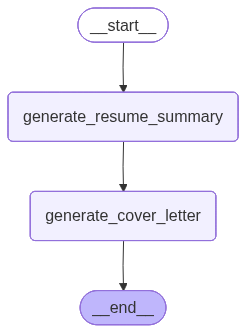

In [48]:
from IPython.display import Image, display

# Generate a visualization of the workflow graph
display(Image(app.get_graph().draw_mermaid_png()))

In [49]:
input_state = {
        "job_description": "We are looking for a data scientist with experience in machine learning, NLP, and Python. Prior work with large datasets and experience deploying models into production is required."
}

result = app.invoke(input_state)
result["resume_summary"]

'Results-driven data scientist with a strong background in machine learning, natural language processing (NLP), and Python programming. Proven experience in working with large datasets and a track record of successfully deploying predictive models into production, driving business growth and informed decision-making through data-driven insights.'

In [50]:
class RouterState(TypedDict):
    user_input: str
    task_type: str
    output: str

In [51]:
class Router(BaseModel):
    role: str = Field(..., description="Decide whether the user wants to summarize a passage  output 'summarize'  or translate text into French oupput translate.")
llm_router=llm.bind_tools([Router])

In [104]:
response = llm_router.invoke("Summarize this , I love the sun it's so warm")
response.tool_calls[0]["args"]["role"]

'summarize'

In [90]:
def router_node(state:RouterState)-> RouterState:
    routing_prompt = f"""
    You are an AI task classifier.
    
    Decide whether the user wants to:
    - "summarize" a passage
    - or "translate" text into French
    
    Respond with just one word: 'summarize' or 'translate'.
    
    User Input: "{state['user_input']}"
    """
    response = llm_router.invoke(routing_prompt)
    return {**state , "task_type": response.tool_calls[0]["args"]["role"]}

In [91]:
def router(state:RouterState)-> str:
    return state["task_type"]

In [93]:
def summarize_node(state: RouterState) -> RouterState:
    prompt = f"Please summarize the following passage:\n\n{state['user_input']}"
    response = llm.invoke(prompt)
    
    return {**state, "task_type": "summarize", "output": response.content}

In [94]:
def translate_node(state: RouterState) -> RouterState:
    prompt = f"Translate the following text to French:\n\n{state['user_input']}"
    response = llm.invoke(prompt)

    return {**state, "task_type": "translate", "output": response.content}

In [95]:
workflow = StateGraph(RouterState)

In [96]:
workflow.add_node("router", router_node)
workflow.add_node("summarize", summarize_node)
workflow.add_node("translate", translate_node)

In [97]:
workflow.set_entry_point("router")

In [98]:
workflow.add_conditional_edges("router",router,{
    "summarize": "summarize",
    "translate": "translate"
})

In [86]:
workflow.set_finish_point("summarize")
workflow.set_finish_point("translate")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [99]:
app = workflow.compile()

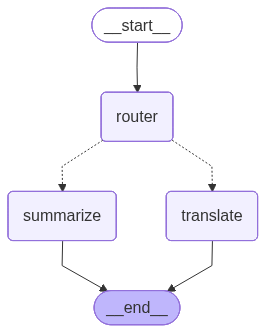

In [100]:
display(Image(app.get_graph().draw_mermaid_png()))

In [101]:
input_text = {
        "user_input": "Can you translate this sentence: I love programming?"
    }

result = app.invoke(input_text)

In [102]:
print(result["output"])
print(result["task_type"])

Pouvez-vous traduire cette phrase : J'adore la programmation ?
translate


In [105]:
input_text = {
        "user_input": "Can you summarize this sentence: I love programming so much it is the best thing ever. All I want to do is programming?"
    }

result = app.invoke(input_text)

In [106]:
print(result["output"])
print(result["task_type"])

The speaker has a strong passion for programming, enjoying it so much that they want to dedicate all their time to it.
summarize


In [107]:
class State(TypedDict):
    text:str
    french:str
    japanese:str
    spanish:str
    combined_output:str

In [108]:
def translate_french(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to French:\n\n{state['text']}")
    return {"french": response.content.strip()}

In [109]:
def translate_spanish(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to Spanish:\n\n{state['text']}")
    return {"spanish": response.content.strip()}

In [110]:
def translate_japanese(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to Japanese:\n\n{state['text']}")
    return {"japanese": response.content.strip()}

In [111]:
def aggregator(state: State) -> dict:
    combined = f"Original Text: {state['text']}\n\n"
    combined += f"French: {state['french']}\n\n"
    combined += f"Spanish: {state['spanish']}\n\n"
    combined += f"Japanese: {state['japanese']}\n"
    return {"combined_output": combined}

In [112]:
graph = StateGraph(State)

In [113]:
graph.add_node("translate_french", translate_french)
graph.add_node("translate_spanish", translate_spanish)
graph.add_node("translate_japanese", translate_japanese)
graph.add_node("aggregator", aggregator)

In [116]:
# Connect parallel nodes from START
graph.add_edge(START, "translate_french")
graph.add_edge(START, "translate_spanish")
graph.add_edge(START, "translate_japanese")

In [117]:
# Connect all translation nodes to the aggregator
graph.add_edge("translate_french", "aggregator")
graph.add_edge("translate_spanish", "aggregator")
graph.add_edge("translate_japanese", "aggregator")

In [118]:
graph.add_edge("aggregator", END)

In [119]:
app = graph.compile()

In [120]:
input_text = {
        "text": "Good morning! I hope you have a wonderful day."
}

result = app.invoke(input_text)
result

{'text': 'Good morning! I hope you have a wonderful day.',
 'french': "Bonjour ! J'espère que vous passez une merveilleuse journée.",
 'japanese': '(Ohayou gozaimasu! Kyou wa subarashii ichinichi ni naru to omoimasu.)',
 'spanish': 'Buenos días. Espero que tengas un día maravilloso.\n\n(Note: A more literal translation of "I hope you have" would be "espero que tengas", but in Spanish, it\'s common to use the subjunctive mood in this context, so the translation could also be "Espero que tengas" or simply "Que tengas un día maravilloso")',
 'combined_output': 'Original Text: Good morning! I hope you have a wonderful day.\n\nFrench: Bonjour ! J\'espère que vous passez une merveilleuse journée.\n\nSpanish: Buenos días. Espero que tengas un día maravilloso.\n\n(Note: A more literal translation of "I hope you have" would be "espero que tengas", but in Spanish, it\'s common to use the subjunctive mood in this context, so the translation could also be "Espero que tengas" or simply "Que tengas 